In [1]:
# ============================================================
# CELL 1: Import Libraries
# ============================================================

import os
import glob
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
# ============================================================
# CELL 2: Load Trained Model
# ============================================================

MODEL_PATH = "models/xgboost_stock_model.pkl"

model = joblib.load(MODEL_PATH)

print("Model loaded successfully!")
print(type(model))

Model loaded successfully!
<class 'xgboost.sklearn.XGBClassifier'>


In [3]:
# ============================================================
# CELL 3: Load All Feature Files
# ============================================================

FEATURE_FOLDER = "data/features"

feature_files = glob.glob(
    os.path.join(FEATURE_FOLDER, "*.csv")
)

print(f"Total feature files found: {len(feature_files)}")

all_data = []

for file in feature_files:
    df = pd.read_csv(file)
    all_data.append(df)

data = pd.concat(all_data, ignore_index=True)

print("Dataset Shape:", data.shape)
data.head()

Total feature files found: 15
Dataset Shape: (39930, 19)


,Date,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_20,RSI,MACD,MACD_Signal,BB_High,BB_Low,Daily_Return,Volatility,Future_Close,Future_Return,Signal
0,2015-03-16,180.199173,182.734928,179.813992,182.210659,13839990,186.268931,188.356171,186.018658,39.340039,-2.031840,-1.521546,196.437827,176.100035,-0.009411,0.016399,180.167068,-0.000178,1
1,2015-03-17,183.355484,184.008143,179.963773,182.007356,19070082,185.620011,188.223285,185.765022,44.958427,-1.986015,-1.614440,194.739171,176.500852,0.017516,0.016843,181.451004,-0.010387,1
2,2015-03-18,185.880554,186.650917,182.895423,183.387595,9269885,185.254627,188.150957,185.776025,49.026011,-1.726050,-1.636762,193.691631,176.817624,0.013771,0.016974,180.798340,-0.027341,0
3,2015-03-19,183.205688,187.603127,182.767012,187.357048,13934612,184.767805,188.066646,185.531231,45.214181,-1.716082,-1.652626,192.465539,177.070071,-0.014390,0.017204,177.460129,-0.031361,0
4,2015-03-20,182.767014,184.275628,181.590071,183.580158,10405717,184.254768,188.143681,185.267972,44.601712,-1.723711,-1.666843,190.989574,177.519963,-0.002394,0.017191,173.693939,-0.049643,0


In [6]:
# ============================================================
# CELL 4: Define Features and Target (FIXED)
# ============================================================

FEATURE_COLUMNS = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "SMA_20",
    "SMA_50",
    "EMA_20",
    "RSI",
    "MACD",
    "MACD_Signal",
    "BB_High",
    "BB_Low",
    "Daily_Return",
    "Volatility"
]

# Target column (this is your actual label)
TARGET_COLUMN = "Signal"

print("Available Columns:\n")
print(data.columns.tolist())

# Check missing features
missing_cols = [col for col in FEATURE_COLUMNS if col not in data.columns]

if missing_cols:
    print("\nMissing Columns:", missing_cols)
else:
    print("\nAll required features are present.")

# Define X and y correctly
X = data[FEATURE_COLUMNS]
y = data[TARGET_COLUMN]

print("\nFeatures Shape:", X.shape)
print("Target Shape:", y.shape)

y.value_counts()

Available Columns:

['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'SMA_20', 'SMA_50', 'EMA_20', 'RSI', 'MACD', 'MACD_Signal', 'BB_High', 'BB_Low', 'Daily_Return', 'Volatility', 'Future_Close', 'Future_Return', 'Signal']

All required features are present.

Features Shape: (39930, 15)
Target Shape: (39930,)


Signal
1    19610
2    11389
0     8931
Name: count, dtype: int64

In [7]:
# ============================================================
# CELL 5: Make Predictions
# ============================================================

y_pred = model.predict(X)

print("Predictions generated successfully!")

Predictions generated successfully!


In [8]:
# ============================================================
# CELL 6: Accuracy Score
# ============================================================

accuracy = accuracy_score(y, y_pred)

print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 60.10%


In [9]:
# ============================================================
# CELL 7: Classification Report
# ============================================================

print(
    classification_report(
        y,
        y_pred,
        target_names=["SELL", "HOLD", "BUY"]
    )
)

              precision    recall  f1-score   support

        SELL       0.91      0.18      0.30      8931
        HOLD       0.56      0.97      0.71     19610
         BUY       0.80      0.29      0.43     11389

    accuracy                           0.60     39930
   macro avg       0.76      0.48      0.48     39930
weighted avg       0.71      0.60      0.54     39930



In [10]:
# ============================================================
# CELL 8: Confusion Matrix
# ============================================================

cm = confusion_matrix(y, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 1615  6921   395]
 [   94 19083   433]
 [   58  8033  3298]]


<Figure size 800x600 with 0 Axes>

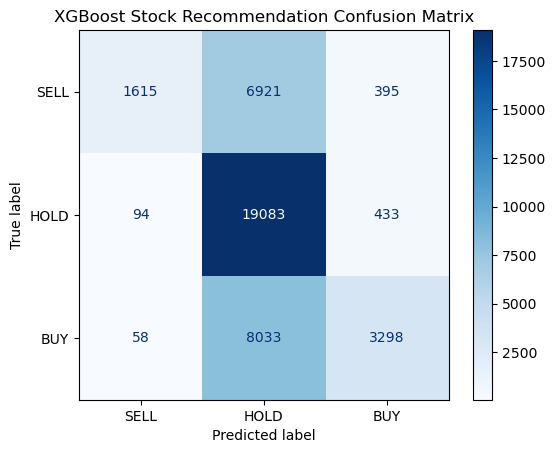

In [11]:
# ============================================================
# CELL 9: Visualize Confusion Matrix
# ============================================================

plt.figure(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["SELL", "HOLD", "BUY"]
)

disp.plot(cmap="Blues")
plt.title("XGBoost Stock Recommendation Confusion Matrix")
plt.show()

In [12]:
# ============================================================
# CELL 10: Feature Importance
# ============================================================

importance = pd.DataFrame({
    "Feature": FEATURE_COLUMNS,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
7,EMA_20,0.077403
12,BB_Low,0.076231
3,Close,0.076227
6,SMA_50,0.075325
14,Volatility,0.074250
11,BB_High,0.074138
5,SMA_20,0.071417
2,Low,0.070349
1,High,0.067911
10,MACD_Signal,0.061661


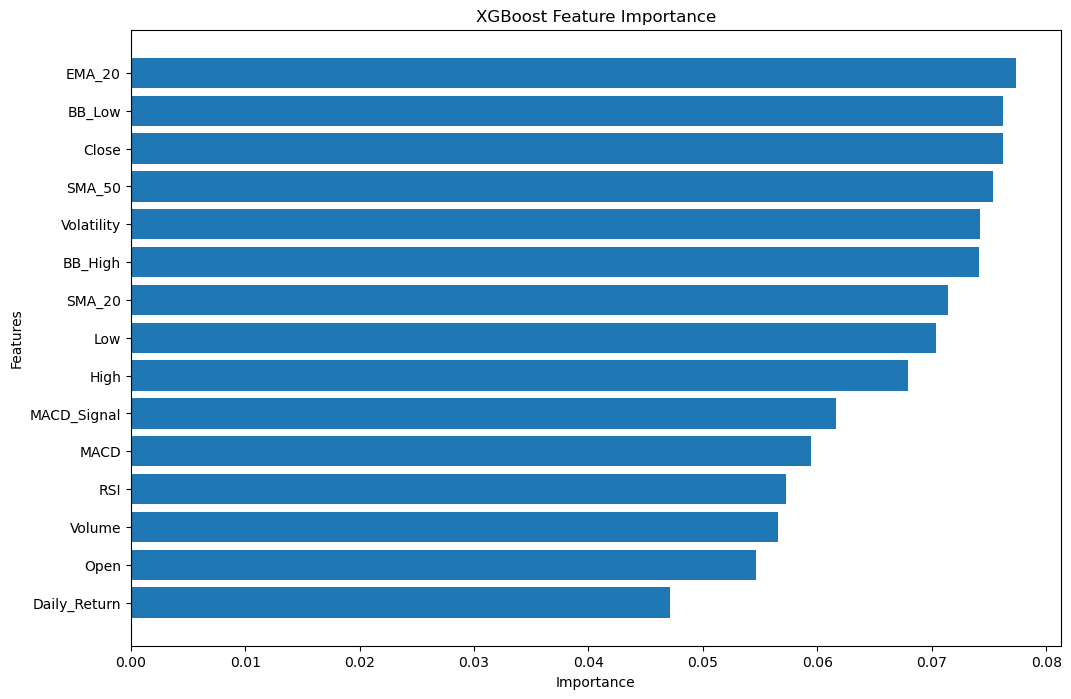

In [13]:
# ============================================================
# CELL 11: Plot Feature Importance
# ============================================================

plt.figure(figsize=(12, 8))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()

plt.show()

In [2]:
import pandas as pd
import numpy as np
import glob
import joblib
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Load all feature files
files = glob.glob("data/features/*.csv")

data = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

print("Data loaded successfully")
print("Shape:", data.shape)

Data loaded successfully
Shape: (39930, 19)


In [3]:
FEATURE_COLUMNS = [
    "Open", "High", "Low", "Close", "Volume",
    "SMA_20", "SMA_50", "EMA_20", "RSI",
    "MACD", "MACD_Signal",
    "BB_High", "BB_Low",
    "Daily_Return", "Volatility"
]

X = data[FEATURE_COLUMNS]
y = data["Signal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train/Test Split Done")

Train/Test Split Done


In [4]:
base_model = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

base_model.fit(X_train, y_train)
base_pred = base_model.predict(X_test)

base_acc = accuracy_score(y_test, base_pred)
base_f1 = f1_score(y_test, base_pred, average="weighted")

print("Base Model Done")

Base Model Done


In [5]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.9],
    "colsample_bytree": [0.7, 0.9]
}

grid = GridSearchCV(
    XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss"
    ),
    param_grid,
    cv=3,
    scoring="f1_weighted",
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
best_pred = best_model.predict(X_test)

best_acc = accuracy_score(y_test, best_pred)
best_f1 = f1_score(y_test, best_pred, average="weighted")

print("Tuning Done")
print("Best Params:", grid.best_params_)

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Tuning Done
Best Params: {'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.7}


In [6]:
results = pd.DataFrame({
    "Model": ["Base XGBoost", "Tuned XGBoost"],
    "Accuracy": [base_acc, best_acc],
    "F1 Score": [base_f1, best_f1]
})

print("\nFINAL RESULTS")
print(results)

print("\nBest Model Report:\n")
print(classification_report(y_test, best_pred))


FINAL RESULTS
           Model  Accuracy  F1 Score
0   Base XGBoost  0.518532  0.414601
1  Tuned XGBoost  0.542324  0.481170

Best Model Report:

              precision    recall  f1-score   support

           0       0.58      0.14      0.23      1786
           1       0.54      0.89      0.67      3922
           2       0.56      0.26      0.36      2278

    accuracy                           0.54      7986
   macro avg       0.56      0.43      0.42      7986
weighted avg       0.55      0.54      0.48      7986



In [7]:
joblib.dump(best_model, "models/xgboost_best.pkl")

print("Model saved: models/xgboost_best.pkl")

Model saved: models/xgboost_best.pkl


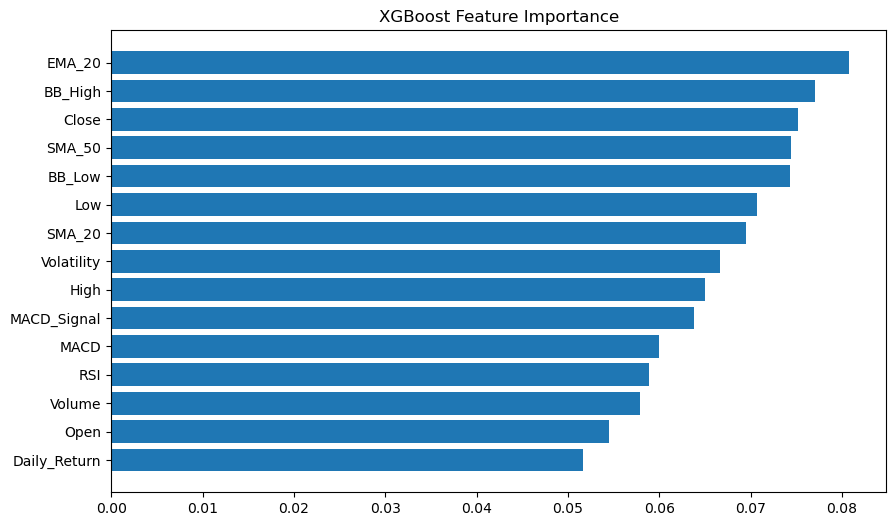

In [8]:
importance = pd.DataFrame({
    "Feature": FEATURE_COLUMNS,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=True)

plt.figure(figsize=(10,6))

plt.barh(importance["Feature"], importance["Importance"])
plt.title("XGBoost Feature Importance")
plt.show()